# Data extraction
We have downloaded the dataset with demographic information for every one of the 8132 municipalities in Spain from the MITECO (Spanish Ministry for the Ecological Transition and the Demographic Challenge) website. We also have downloaded the electoral results for the july 2023 and november 2019 general elections in Spain from the Spanish Ministry for the Interior, which are in a Excel format.

The implementation of most of the funcions for data extraction are in the `src/data_extraction.py` file. 

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

from src import data_extraction as de
from src.config import *

## `load_miteco` Function

The `load_miteco` function extracts the geographical data from the MITECO dataset a GeoDataFrame with the geographical data of the municipalities in Spain. Although MITECO sources this information from the Spanish National Geographic Institute (IGN), we use the MITECO dataset directly to avoid several drawbacks of the raw IGN data. Specifically, the IGN data is split into separate files with different projections for the mainland and the Canary Islands, and it includes additional local administrative entities. MITECO provides a highly convenient, preprocessed dataset that is already geographically unified and strictly filtered to include only municipalities.

We have the following data:

### Sapatial Variables
- `geometry`: Geometrical shape of the municipality (polygon)
- `Latitude`: Latitude of the centroid of the municipality
- `Longitude`: Longitude of the centroid of the municipality
- `Area in km2`: Area of the municipality in square kilometers

### Geographical Identifiers
- `Code of Municipality`: Unique code for each municipality asigned by the INE (Spanish National Statistics Institute)
- `Name of Municipality`: Name of the municipality
- `Code of Autonomous Community`: Unique code for each autonomous community asigned by the INE
- `Name of Autonomous Community`: Name of the autonomous community
- `Code of Province`: Unique code for each province asigned by the INE
- `Name of Province`: Name of the province



In [4]:
gdf_miteco = de.load_miteco()
print(gdf_miteco.columns)
gdf_miteco

c:\Users\rodri\Mis archivos\Académico\Universidad\UCM\5º Mat-Inf\TFG Informática\tfg_electoral_analysis_spain_2023\src\data_extraction.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_wgs84 = gdf.geometry.centroid.to_crs(epsg=4326)


Index(['Code of municipality', 'Name of municipality',
       'Code of autonomous community', 'Name of autonomous community',
       'Code of province', 'Name of province', 'Area in km2', 'Latitude',
       'Longitude', 'geometry'],
      dtype='str')


,Code of municipality,Name of municipality,Code of autonomous community,Name of autonomous community,Code of province,Name of province,Area in km2,Latitude,Longitude,geometry
0,38046,Tegueste,05,Canarias,38,Santa Cruz de Tenerife,27.561485,28.520048,-16.335848,"POLYGON ((-16.32911 28.50832, -16.32953 28.508..."
1,38047,Tijarafe,05,Canarias,38,Santa Cruz de Tenerife,56.406628,28.711065,-17.945638,"POLYGON ((-17.99258 28.74029, -17.99193 28.741..."
2,38048,Valverde,05,Canarias,38,Santa Cruz de Tenerife,109.320822,27.785268,-17.943905,"MULTIPOLYGON (((-18.02365 27.72846, -18.02346 ..."
3,38049,Valle Gran Rey,05,Canarias,38,Santa Cruz de Tenerife,33.798537,28.123422,-17.318657,"MULTIPOLYGON (((-17.33579 28.15197, -17.3355 2..."
4,38050,Vallehermoso,05,Canarias,38,Santa Cruz de Tenerife,113.873292,28.142424,-17.284484,"MULTIPOLYGON (((-17.34199 28.15426, -17.34207 ..."
...,...,...,...,...,...,...,...,...,...,...
8126,26164,Ventrosa,17,La Rioja,26,La Rioja,72.870545,42.169368,-2.839778,"POLYGON ((-2.89399 42.22385, -2.89393 42.22442..."
8127,26166,Villalba de Rioja,17,La Rioja,26,La Rioja,8.952335,42.606980,-2.892934,"POLYGON ((-2.9128 42.60152, -2.91239 42.60203,..."
8128,26177,Villoslada de Cameros,17,La Rioja,26,La Rioja,94.631158,42.067822,-2.691884,"POLYGON ((-2.75758 42.03262, -2.75738 42.0331,..."
8129,26179,Viniegra de Arriba,17,La Rioja,26,La Rioja,38.429761,42.079430,-2.824885,"POLYGON ((-2.85189 42.1187, -2.84839 42.11463,..."


In [5]:
# Drop geometry (keep only tabular data) and Save to Excel
gdf_miteco.drop(columns='geometry').to_excel(f'01_data_miteco.xlsx', index=False)

## `load_demographics_ine` Function
The `load_demographics_ine` function extracts the demographic data from the INE (Spanish National Statistics Institute) annual population census, which is in a CSV format. The data is extracted for the year 2023, and it contains the following variables:
- `Population in 2023`
- `Mean age`
- `Foreign-born population (%)`

Combining the data from MITECO and INE, we can also compute the population density of each municipality (`Population density (inhabitants/km2)`), which is the population divided by the area of the municipality.

In [6]:
df_demographics = de.load_demographics_ine()
print(df_demographics.columns)
df_demographics

Index(['Code of municipality', 'Population in 2023', 'Mean age',
       'Foreign-born population (%)'],
      dtype='str')


,Code of municipality,Population in 2023,Mean age,Foreign-born population (%)
0,01001,2969.0,40.54,14.651398
1,01002,10299.0,45.63,9.865035
2,01003,1409.0,46.73,3.903478
3,01004,1832.0,43.76,8.187773
4,01006,233.0,43.73,11.587983
...,...,...,...,...
8127,50901,165.0,56.63,13.939394
8128,50902,87.0,56.13,1.149425
8129,50903,2864.0,45.98,8.414804
8130,51001,83052.0,38.56,12.604152


In [7]:
gdf_demographics = gdf_miteco.merge(df_demographics, on='Code of municipality', how='left')
gdf_demographics = de.compute_population_density(gdf_demographics)
print(gdf_demographics.columns)
gdf_demographics

Index(['Code of municipality', 'Name of municipality',
       'Code of autonomous community', 'Name of autonomous community',
       'Code of province', 'Name of province', 'Area in km2', 'Latitude',
       'Longitude', 'geometry', 'Population in 2023', 'Mean age',
       'Foreign-born population (%)', 'Population density (inhabitants/km2)'],
      dtype='str')


,Code of municipality,Name of municipality,Code of autonomous community,Name of autonomous community,Code of province,Name of province,Area in km2,Latitude,Longitude,geometry,Population in 2023,Mean age,Foreign-born population (%),Population density (inhabitants/km2)
0,38046,Tegueste,05,Canarias,38,Santa Cruz de Tenerife,27.561485,28.520048,-16.335848,"POLYGON ((-16.32911 28.50832, -16.32953 28.508...",11375.0,44.54,7.621978,412.713611
1,38047,Tijarafe,05,Canarias,38,Santa Cruz de Tenerife,56.406628,28.711065,-17.945638,"POLYGON ((-17.99258 28.74029, -17.99193 28.741...",2632.0,49.25,28.685410,46.661183
2,38048,Valverde,05,Canarias,38,Santa Cruz de Tenerife,109.320822,27.785268,-17.943905,"MULTIPOLYGON (((-18.02365 27.72846, -18.02346 ...",5149.0,46.71,22.684016,47.099902
3,38049,Valle Gran Rey,05,Canarias,38,Santa Cruz de Tenerife,33.798537,28.123422,-17.318657,"MULTIPOLYGON (((-17.33579 28.15197, -17.3355 2...",4705.0,48.34,41.445271,139.207211
4,38050,Vallehermoso,05,Canarias,38,Santa Cruz de Tenerife,113.873292,28.142424,-17.284484,"MULTIPOLYGON (((-17.34199 28.15426, -17.34207 ...",2940.0,52.99,18.435374,25.818170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,26164,Ventrosa,17,La Rioja,26,La Rioja,72.870545,42.169368,-2.839778,"POLYGON ((-2.89399 42.22385, -2.89393 42.22442...",53.0,56.76,7.547170,0.727317
8127,26166,Villalba de Rioja,17,La Rioja,26,La Rioja,8.952335,42.606980,-2.892934,"POLYGON ((-2.9128 42.60152, -2.91239 42.60203,...",170.0,51.81,7.058824,18.989459
8128,26177,Villoslada de Cameros,17,La Rioja,26,La Rioja,94.631158,42.067822,-2.691884,"POLYGON ((-2.75758 42.03262, -2.75738 42.0331,...",347.0,52.59,10.951009,3.666868
8129,26179,Viniegra de Arriba,17,La Rioja,26,La Rioja,38.429761,42.079430,-2.824885,"POLYGON ((-2.85189 42.1187, -2.84839 42.11463,...",41.0,62.60,2.439024,1.066881


In [8]:
gdf_demographics.drop(columns='geometry').to_excel(f'01_data_demographics.xlsx', index=False)

## `load_higher_education_ine` Function
The `load_higher_education_ine` function extracts the data on the percentage of the population older than 15 with higher education from the INE (Spanish National Statistics Institute) annual population census, which is in a CSV format. The data is extracted for the year 2023, and it adds to our dataset the variable:
- `Population with higher education (%)`

In [9]:
gdf_higher_education = de.load_higher_education_ine()
print(gdf_higher_education.columns)
gdf_higher_education

Index(['Code of municipality', 'Population with higher education (%)'], dtype='str')


,Code of municipality,Population with higher education (%)
0,01001,43.026101
1,01002,39.544727
2,01003,53.013029
3,01004,44.125326
4,01006,40.579710
...,...,...
8126,50901,38.125000
8127,50902,41.666667
8128,50903,33.557312
8129,51001,25.838837


## `load_economic_ine` Function
The `load_economic_ine` function extracts the economic data from the INE (Spanish National Statistics Institute) household income distribution atlas, which is in different CSV files. The data is extracted for the year 2023, and it contains the following variables:

- `Mean net income per person`

In [10]:
df_economic = de.load_economic_ine()
print(df_economic.columns)
df_economic

Index(['Code of municipality', 'Mean net income per person'], dtype='str')


,Code of municipality,Mean net income per person
0,01001,16429.0
216,01002,17486.0
702,01003,20577.0
864,01004,16408.0
1026,01006,17000.0
...,...,...
3002508,50901,20063.0
3002670,50902,16463.0
3002832,50903,16099.0
3003048,51001,14625.0


## `load_population_change_ine` Function
The `load_population_change_ine` function extracts the population change data from the INE (Spanish National Statistics Institute) municipal register for the years 2019 and 2023, which is in a Excel format. We can not use data from the census due to it not being available annually before 2021. Until 2021, census used to be conducted every ten years, it was in 2021 when it became annual. We use this data to compute the population change between 2019 and 2023 as follows:

- `Population change (%)` = ((`Population in 2023` - `Population in 2019`) / `Population in 2019`) * 100

In [11]:
df_population_change = de.load_population_change_ine()
print(df_population_change.columns)
df_population_change

Index(['Code of municipality', 'Population change from 2019 to 2023 (%)'], dtype='str')


,Code of municipality,Population change from 2019 to 2023 (%)
0,02001,-3.797468
1,02002,-5.394990
2,02003,-0.070963
3,02004,-5.346821
4,02005,1.215805
...,...,...
8126,50282,-12.500000
8127,50295,4.081633
8128,50296,0.919540
8129,50297,1.113486


## `load_unemployment` Function
The `load_unemployment` function extracts the unemployment data from the SEPE (Spanish Public Employment Service) dataset on unemployment by municipalities, which is in a CSV format. It contains the total number of unemployed people for each municipality each month of the year 2023. As economical activity is not equaly distributed around a year, for instance in costal areas unemployment is lower during the summer, we compute the average of that figure for the whole year 2023. In some small municipalities, due to statistical confidentiality, the data may be suppressed indicating a value `<5`. In those cases, we replace the value with `2.5`. 

In order to obtain a standardized measure, we calculate the unemployment rate per 1000 inhabitants by combining this data with the previous dataset in the function `compute_unemployment_per_1000`. The data is extracted for the year 2023, and it contains the following variable:
- `Unemployment per 1000 inhabitants` = (`Number of unemployed people` / `Population`) * 1000

In [12]:
df_unemployment = de.load_unemployment()
print(df_unemployment.columns)
df_unemployment

Index(['Code of municipality', 'total Paro Registrado'], dtype='str')


,Code of municipality,total Paro Registrado
0,01001,175.416667
1,01002,738.583333
2,01003,4.125000
3,01004,93.500000
4,01006,14.833333
...,...,...
8129,50901,5.166667
8130,50902,0.416667
8131,50903,86.916667
8132,51001,10116.083333


In [13]:
df_unemployment_combined = de.compute_unemployment_per_1000(gdf_demographics, df_unemployment)
print(df_unemployment_combined.columns)
df_unemployment_combined

Index(['Code of municipality', 'Name of municipality',
       'Code of autonomous community', 'Name of autonomous community',
       'Code of province', 'Name of province', 'Area in km2', 'Latitude',
       'Longitude', 'geometry', 'Population in 2023', 'Mean age',
       'Foreign-born population (%)', 'Population density (inhabitants/km2)',
       'Unemployment per 1000 inhabitants'],
      dtype='str')


,Code of municipality,Name of municipality,Code of autonomous community,Name of autonomous community,Code of province,Name of province,Area in km2,Latitude,Longitude,geometry,Population in 2023,Mean age,Foreign-born population (%),Population density (inhabitants/km2),Unemployment per 1000 inhabitants
0,38046,Tegueste,05,Canarias,38,Santa Cruz de Tenerife,27.561485,28.520048,-16.335848,"POLYGON ((-16.32911 28.50832, -16.32953 28.508...",11375.0,44.54,7.621978,412.713611,70.263736
1,38047,Tijarafe,05,Canarias,38,Santa Cruz de Tenerife,56.406628,28.711065,-17.945638,"POLYGON ((-17.99258 28.74029, -17.99193 28.741...",2632.0,49.25,28.685410,46.661183,75.259625
2,38048,Valverde,05,Canarias,38,Santa Cruz de Tenerife,109.320822,27.785268,-17.943905,"MULTIPOLYGON (((-18.02365 27.72846, -18.02346 ...",5149.0,46.71,22.684016,47.099902,65.999871
3,38049,Valle Gran Rey,05,Canarias,38,Santa Cruz de Tenerife,33.798537,28.123422,-17.318657,"MULTIPOLYGON (((-17.33579 28.15197, -17.3355 2...",4705.0,48.34,41.445271,139.207211,43.464400
4,38050,Vallehermoso,05,Canarias,38,Santa Cruz de Tenerife,113.873292,28.142424,-17.284484,"MULTIPOLYGON (((-17.34199 28.15426, -17.34207 ...",2940.0,52.99,18.435374,25.818170,56.802721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,26164,Ventrosa,17,La Rioja,26,La Rioja,72.870545,42.169368,-2.839778,"POLYGON ((-2.89399 42.22385, -2.89393 42.22442...",53.0,56.76,7.547170,0.727317,39.308176
8127,26166,Villalba de Rioja,17,La Rioja,26,La Rioja,8.952335,42.606980,-2.892934,"POLYGON ((-2.9128 42.60152, -2.91239 42.60203,...",170.0,51.81,7.058824,18.989459,14.705882
8128,26177,Villoslada de Cameros,17,La Rioja,26,La Rioja,94.631158,42.067822,-2.691884,"POLYGON ((-2.75758 42.03262, -2.75738 42.0331,...",347.0,52.59,10.951009,3.666868,40.345821
8129,26179,Viniegra de Arriba,17,La Rioja,26,La Rioja,38.429761,42.079430,-2.824885,"POLYGON ((-2.85189 42.1187, -2.84839 42.11463,...",41.0,62.60,2.439024,1.066881,15.243902


## `load_affiliation` Function
The `load_affiliation` function extracts the affiliation data from the Social Security dataset on affiliation by municipalities, which is in a Excel format for each month. As economical activity is not equaly distributed around a year, for instance in costal areas affiliation is higher during the summer, we compute the average of that figure for the whole year 2023. In some small municipalities, due to statistical confidentiality, the data may be suppressed indicating a value `<5`. In those cases, we replace the value with `2.5`.

In order to obtain a standardized measure, we calculate the affiliation rate per 1000 inhabitants by combining this data with the previous dataset in the function `compute_affiliation_per_1000`. The data is extracted for the year 2023, and it contains the following variable:
- `Affiliation per 1000 inhabitants` = (`Number of affiliated people` / `Population`) * 1000

In [23]:
df_affiliation = de.load_affiliation()
print(df_affiliation.columns)
df_affiliation

Index(['Code of municipality', 'TOTAL'], dtype='str')


,Code of municipality,TOTAL
0,01001,646.583333
1,01002,3999.833333
2,01003,238.833333
3,01004,406.666667
4,01006,146.500000
...,...,...
8120,50903,757.666667
8121,51001,22867.916667
8122,52001,24446.916667
8123,NO DI,5097.849359


In [24]:
df_affiliation_combined = de.compute_affiliation_per_1000(gdf_demographics, df_affiliation)
print(df_affiliation_combined.columns)
df_affiliation_combined

Index(['Code of municipality', 'Name of municipality',
       'Code of autonomous community', 'Name of autonomous community',
       'Code of province', 'Name of province', 'Area in km2', 'Latitude',
       'Longitude', 'geometry', 'Population in 2023', 'Mean age',
       'Foreign-born population (%)', 'Population density (inhabitants/km2)',
       'Affiliation to Social Security per 1000 inhabitants'],
      dtype='str')


,Code of municipality,Name of municipality,Code of autonomous community,Name of autonomous community,Code of province,Name of province,Area in km2,Latitude,Longitude,geometry,Population in 2023,Mean age,Foreign-born population (%),Population density (inhabitants/km2),Affiliation to Social Security per 1000 inhabitants
0,38046,Tegueste,05,Canarias,38,Santa Cruz de Tenerife,27.561485,28.520048,-16.335848,"POLYGON ((-16.32911 28.50832, -16.32953 28.508...",11375.0,44.54,7.621978,412.713611,197.787546
1,38047,Tijarafe,05,Canarias,38,Santa Cruz de Tenerife,56.406628,28.711065,-17.945638,"POLYGON ((-17.99258 28.74029, -17.99193 28.741...",2632.0,49.25,28.685410,46.661183,325.322948
2,38048,Valverde,05,Canarias,38,Santa Cruz de Tenerife,109.320822,27.785268,-17.943905,"MULTIPOLYGON (((-18.02365 27.72846, -18.02346 ...",5149.0,46.71,22.684016,47.099902,332.265165
3,38049,Valle Gran Rey,05,Canarias,38,Santa Cruz de Tenerife,33.798537,28.123422,-17.318657,"MULTIPOLYGON (((-17.33579 28.15197, -17.3355 2...",4705.0,48.34,41.445271,139.207211,256.978392
4,38050,Vallehermoso,05,Canarias,38,Santa Cruz de Tenerife,113.873292,28.142424,-17.284484,"MULTIPOLYGON (((-17.34199 28.15426, -17.34207 ...",2940.0,52.99,18.435374,25.818170,154.676871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,26164,Ventrosa,17,La Rioja,26,La Rioja,72.870545,42.169368,-2.839778,"POLYGON ((-2.89399 42.22385, -2.89393 42.22442...",53.0,56.76,7.547170,0.727317,171.383648
8127,26166,Villalba de Rioja,17,La Rioja,26,La Rioja,8.952335,42.606980,-2.892934,"POLYGON ((-2.9128 42.60152, -2.91239 42.60203,...",170.0,51.81,7.058824,18.989459,212.254902
8128,26177,Villoslada de Cameros,17,La Rioja,26,La Rioja,94.631158,42.067822,-2.691884,"POLYGON ((-2.75758 42.03262, -2.75738 42.0331,...",347.0,52.59,10.951009,3.666868,157.300672
8129,26179,Viniegra de Arriba,17,La Rioja,26,La Rioja,38.429761,42.079430,-2.824885,"POLYGON ((-2.85189 42.1187, -2.84839 42.11463,...",41.0,62.60,2.439024,1.066881,170.731707


## `load_infoelectoral` Function

The `load_infoelectoral` function extracts the electoral data from the Infoelectoral .xlsx files for the july 2023 and november 2019 general elections in Spain. The data is extracted for the following parties: PP, PSOE, VOX, SUMAR. The function returns a DataFrame containing the combined data from all Infoelectoral .xlsx files. The DataFrame has the following columns:

- `Code of Municipality`: Code of the municipality from the INE (Instituto Nacional de Estadística)
- `Number of votes in 2023`: Number of valid votes in the 2023 general election
- `Votes for PP in 2023 (%)`: % of votes for the PP party in the 2023 general election
- `Votes for PSOE in 2023 (%)`: % of votes for the PSOE party in the 2023 general election
- `Votes for VOX in 2023 (%)`: % of votes for the VOX party in the 2023 general election
- `Votes for SUMAR in 2023 (%)`: % of votes for the SUMAR party in the 2023 general election
- `Number of votes in 2019`: Number of valid votes in the 2019 general election
- `Votes for PP in 2019 (%)`: % of votes for the PP party in the 2019 general election
- `Votes for PSOE in 2019 (%)`: % of votes for the PSOE party in the 2019 general election
- `Votes for VOX in 2019 (%)`: % of votes for the VOX party in the 2019 general election
- `Votes for SUMAR in 2019 (%)`: % of votes for the SUMAR party in the 2019 general election

*Note:* SUMAR is a coalition of left-wing parties that was formed for the 2023 general election, so for the 2019 general election, the % of votes for SUMAR is calculated as the sum of the % of votes for the parties that form the SUMAR coalition (Podemos, Izquierda Unida, Más País, Equo, Compromís, etc.).

*Note:* In the province of Navarra, PP did not present candidacies in the 2019. Instead, the right-wing coalition Navarra Suma (NA+) (which included mainly PP and UPN) presented candidacies. On the other hand, in the 2023 general election, PP and UPN presented candidacies separately. As PP and UPN are sociologically very similar parties and UPN is only present in Navarra, we have considered the votes for UPN as votes for PP in the province of Navarra for both the 2019 and 2023 general elections. Therefore, in the province of Navarra, the % of votes for PP in 2023 is calculated as the sum of the % of votes for PP and UPN, and the % of votes for PP in 2019 is calculated as the % of votes for the Navarra Suma coalition in the 2019 general election.

*Note:* In 2023, Vox did not present candidacies in the Tenerife province. Therefore, the % of votes for Vox in the Tenerife province in 2023 is set to 0.

In [14]:
df_infoelectoral = de.load_infoelectoral()
print(df_infoelectoral.columns)
df_infoelectoral

Index(['Code of municipality', 'Number of votes in 2023',
       'Votes for PSOE in 2023 (%)', 'Votes for VOX in 2023 (%)',
       'Votes for SUMAR in 2023 (%)', 'Votes for PP in 2023 (%)',
       'Number of votes in 2019', 'Votes for PSOE in 2019 (%)',
       'Votes for VOX in 2019 (%)', 'Votes for PP in 2019 (%)',
       'Votes for SUMAR in 2019 (%)'],
      dtype='str')


,Code of municipality,Number of votes in 2023,Votes for PSOE in 2023 (%),Votes for VOX in 2023 (%),Votes for SUMAR in 2023 (%),Votes for PP in 2023 (%),Number of votes in 2019,Votes for PSOE in 2019 (%),Votes for VOX in 2019 (%),Votes for PP in 2019 (%),Votes for SUMAR in 2019 (%)
0,01001,1348,27.299703,4.821958,12.462908,10.459941,1372,20.699708,3.935860,8.309038,18.148688
1,01002,5610,22.994652,2.352941,10.213904,6.880570,5786,16.073280,2.661597,5.841687,14.967162
2,01003,731,7.523940,0.683995,9.302326,0.273598,837,3.106332,0.597372,0.358423,9.318996
3,01004,992,19.758065,3.326613,11.088710,10.383065,945,11.428571,3.492063,8.888889,15.555556
4,01006,134,20.895522,11.194030,14.179104,23.134328,122,16.393443,14.754098,17.213115,22.950820
...,...,...,...,...,...,...,...,...,...,...,...
8126,50901,122,29.508197,15.573770,13.934426,37.704918,96,34.375000,21.875000,18.750000,15.625000
8127,50902,68,29.411765,13.235294,0.000000,54.411765,62,24.193548,16.129032,46.774194,6.451613
8128,50903,1676,25.954654,19.749403,18.556086,31.801909,1670,25.928144,20.299401,19.341317,23.113772
8129,51001,33233,33.999338,23.296121,2.443354,38.777721,33265,31.279122,35.274312,22.266647,3.868931


## `compute_vote_differences` Function
The `compute_vote_differences` function computes the differences in the % of votes for each party between the 2023 and 2019 general elections. The function takes as input the DataFrame returned by the `load_infoelectoral` and adds new columns to the DataFrame with the differences in the % of votes for each party between the 2023 and 2019 general elections. The new columns are named as follows:
- `Vote difference for PP from 2019 to 2023`: Difference in the % of votes for the PP party between the 2023 and 2019 general elections
- `Vote difference for PSOE from 2019 to 2023`: Difference in the % of votes for the PSOE party between the 2023 and 2019 general elections
- `Vote difference for VOX from 2019 to 2023`: Difference in the % of votes for the VOX party between the 2023 and 2019 general elections
- `Vote difference for SUMAR from 2019 to 2023`: Difference in the % of votes for the SUMAR party between the 2023 and 2019 general elections

In [15]:
parties = ['PP', 'PSOE', 'VOX', 'SUMAR']
df_infoelectoral = de.compute_vote_differences(df_infoelectoral, parties, '2019', '2023')
print(df_infoelectoral.columns)
df_infoelectoral

Index(['Code of municipality', 'Number of votes in 2023',
       'Votes for PSOE in 2023 (%)', 'Votes for VOX in 2023 (%)',
       'Votes for SUMAR in 2023 (%)', 'Votes for PP in 2023 (%)',
       'Number of votes in 2019', 'Votes for PSOE in 2019 (%)',
       'Votes for VOX in 2019 (%)', 'Votes for PP in 2019 (%)',
       'Votes for SUMAR in 2019 (%)',
       'Vote difference for PP from 2019 to 2023',
       'Vote difference for PSOE from 2019 to 2023',
       'Vote difference for VOX from 2019 to 2023',
       'Vote difference for SUMAR from 2019 to 2023'],
      dtype='str')


,Code of municipality,Number of votes in 2023,Votes for PSOE in 2023 (%),Votes for VOX in 2023 (%),Votes for SUMAR in 2023 (%),Votes for PP in 2023 (%),Number of votes in 2019,Votes for PSOE in 2019 (%),Votes for VOX in 2019 (%),Votes for PP in 2019 (%),Votes for SUMAR in 2019 (%),Vote difference for PP from 2019 to 2023,Vote difference for PSOE from 2019 to 2023,Vote difference for VOX from 2019 to 2023,Vote difference for SUMAR from 2019 to 2023
0,01001,1348,27.299703,4.821958,12.462908,10.459941,1372,20.699708,3.935860,8.309038,18.148688,2.150903,6.599995,0.886098,-5.685780
1,01002,5610,22.994652,2.352941,10.213904,6.880570,5786,16.073280,2.661597,5.841687,14.967162,1.038884,6.921372,-0.308656,-4.753258
2,01003,731,7.523940,0.683995,9.302326,0.273598,837,3.106332,0.597372,0.358423,9.318996,-0.084825,4.417608,0.086623,-0.016671
3,01004,992,19.758065,3.326613,11.088710,10.383065,945,11.428571,3.492063,8.888889,15.555556,1.494176,8.329493,-0.165451,-4.466846
4,01006,134,20.895522,11.194030,14.179104,23.134328,122,16.393443,14.754098,17.213115,22.950820,5.921214,4.502080,-3.560069,-8.771715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,50901,122,29.508197,15.573770,13.934426,37.704918,96,34.375000,21.875000,18.750000,15.625000,18.954918,-4.866803,-6.301230,-1.690574
8127,50902,68,29.411765,13.235294,0.000000,54.411765,62,24.193548,16.129032,46.774194,6.451613,7.637571,5.218216,-2.893738,-6.451613
8128,50903,1676,25.954654,19.749403,18.556086,31.801909,1670,25.928144,20.299401,19.341317,23.113772,12.460592,0.026510,-0.549998,-4.557687
8129,51001,33233,33.999338,23.296121,2.443354,38.777721,33265,31.279122,35.274312,22.266647,3.868931,16.511074,2.720216,-11.978191,-1.425577


In [16]:
df_infoelectoral.to_excel(f'01_data_infoelectoral.xlsx', index=False)

## `extract_data` Function

The `extract_data` function combines the demographic data from the MITECO dataset and the electoral data from the Infoelectoral .xlsx files. It merges the two datasets based on the municipality codes, computes the vote differences, and returns a single GeoDataFrame that contains both demographic and electoral information for each municipality in Spain.

In [17]:
gdf = de.extract_data()
print(gdf.columns)
gdf

c:\Users\rodri\Mis archivos\Académico\Universidad\UCM\5º Mat-Inf\TFG Informática\tfg_electoral_analysis_spain_2023\src\data_extraction.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_wgs84 = gdf.geometry.centroid.to_crs(epsg=4326)


MITECO data loaded with 8131 records.
Demographic data loaded with 8132 records.
Population density computed and merged with MITECO data.
Higher education data merged with 8131 records.
Income data merged with 8131 records.
Population change data merged with 8131 records.
Unemployment data merged and standardized with 8131 records.
Infoelectoral data loaded with 8131 records.
Data combined with 8131 records after merging.
Vote differences computed for parties: PP, PSOE, VOX, SUMAR
Index(['Code of municipality', 'Name of municipality',
       'Code of autonomous community', 'Name of autonomous community',
       'Code of province', 'Name of province', 'Area in km2', 'Latitude',
       'Longitude', 'geometry', 'Population in 2023', 'Mean age',
       'Foreign-born population (%)', 'Population density (inhabitants/km2)',
       'Population with higher education (%)', 'Mean net income per person',
       'Population change from 2019 to 2023 (%)',
       'Unemployment per 1000 inhabitants',

,Code of municipality,Name of municipality,Code of autonomous community,Name of autonomous community,Code of province,Name of province,Area in km2,Latitude,Longitude,geometry,...,Votes for PP in 2023 (%),Number of votes in 2019,Votes for PSOE in 2019 (%),Votes for VOX in 2019 (%),Votes for PP in 2019 (%),Votes for SUMAR in 2019 (%),Vote difference for PP from 2019 to 2023,Vote difference for PSOE from 2019 to 2023,Vote difference for VOX from 2019 to 2023,Vote difference for SUMAR from 2019 to 2023
0,01001,Alegría-Dulantzi,16,País Vasco-Euskadi,01,Araba-Álava,19.931287,42.829133,-2.511082,"MULTIPOLYGON (((-2.52642 42.83195, -2.52663 42...",...,10.459941,1372,20.699708,3.935860,8.309038,18.148688,2.150903,6.599995,0.886098,-5.685780
1,01002,Amurrio,16,País Vasco-Euskadi,01,Araba-Álava,96.219760,43.025656,-2.971893,"MULTIPOLYGON (((-3.01619 43.04059, -3.01575 43...",...,6.880570,5786,16.073280,2.661597,5.841687,14.967162,1.038884,6.921372,-0.308656,-4.753258
2,01003,Aramaio,16,País Vasco-Euskadi,01,Araba-Álava,73.033118,43.045985,-2.593614,"POLYGON ((-2.66113 43.06576, -2.66102 43.06587...",...,0.273598,837,3.106332,0.597372,0.358423,9.318996,-0.084825,4.417608,0.086623,-0.016671
3,01004,Artziniega,16,País Vasco-Euskadi,01,Araba-Álava,27.264329,43.129709,-3.141468,"POLYGON ((-3.14189 43.16115, -3.14159 43.16111...",...,10.383065,945,11.428571,3.492063,8.888889,15.555556,1.494176,8.329493,-0.165451,-4.466846
4,01006,Armiñón,16,País Vasco-Euskadi,01,Araba-Álava,12.962355,42.714114,-2.873388,"MULTIPOLYGON (((-2.8803 42.69937, -2.87852 42....",...,23.134328,122,16.393443,14.754098,17.213115,22.950820,5.921214,4.502080,-3.560069,-8.771715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,50901,Biel,02,Aragón,50,Zaragoza,130.716159,42.369125,-0.912651,"POLYGON ((-0.97101 42.32159, -0.97134 42.32184...",...,37.704918,96,34.375000,21.875000,18.750000,15.625000,18.954918,-4.866803,-6.301230,-1.690574
8127,50902,Marracos,02,Aragón,50,Zaragoza,17.004302,42.081172,-0.782404,"POLYGON ((-0.80508 42.09643, -0.80486 42.09697...",...,54.411765,62,24.193548,16.129032,46.774194,6.451613,7.637571,5.218216,-2.893738,-6.451613
8128,50903,Villamayor de Gállego,02,Aragón,50,Zaragoza,89.366567,41.693144,-0.739623,"POLYGON ((-0.76496 41.64799, -0.76526 41.64853...",...,31.801909,1670,25.928144,20.299401,19.341317,23.113772,12.460592,0.026510,-0.549998,-4.557687
8129,51001,Ceuta,18,Ciudad Autónoma de Ceuta,51,Ceuta,19.871670,35.893598,-5.342890,"POLYGON ((-5.38206 35.9124, -5.38192 35.91248,...",...,38.777721,33265,31.279122,35.274312,22.266647,3.868931,16.511074,2.720216,-11.978191,-1.425577


In [18]:
gdf.drop(columns='geometry').to_excel(f'01_data_combined.xlsx', index=False)

In [19]:
# Check for missing values
print(gdf.isnull().sum())

Code of municipality                             0
Name of municipality                             0
Code of autonomous community                     0
Name of autonomous community                     0
Code of province                                 0
Name of province                                 0
Area in km2                                      0
Latitude                                         0
Longitude                                        0
geometry                                         0
Population in 2023                               0
Mean age                                         0
Foreign-born population (%)                      0
Population density (inhabitants/km2)             0
Population with higher education (%)           568
Mean net income per person                      73
Population change from 2019 to 2023 (%)          0
Unemployment per 1000 inhabitants                0
Number of votes in 2023                          0
Votes for PSOE in 2023 (%)     

In [20]:
#Sample 1000 rows to keep it fast
# Save the map as an HTML
m = gdf.explore()
m.save('01_map_output.html')
print("Map saved to 01_map_output.html - open it in your browser (Note: it is heavy, it will consume a lot of memory and may be slow to load)")

Map saved to 01_map_output.html - open it in your browser (Note: it is heavy, it will consume a lot of memory and may be slow to load)


<Axes: >

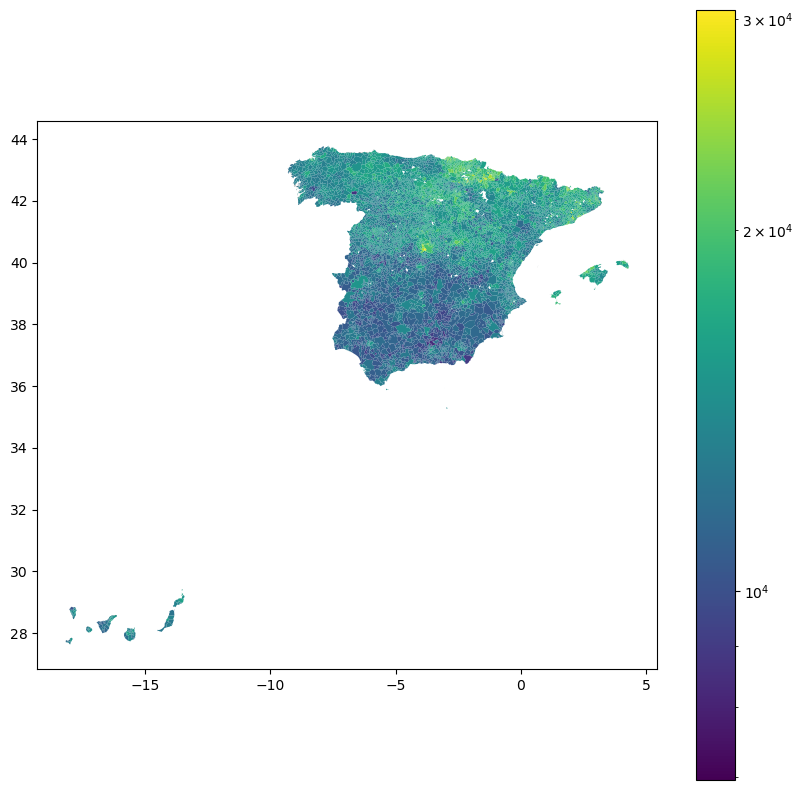

In [21]:
import matplotlib

# Log scale coloring
gdf.plot(column=V_MEAN_NET_INCOME, legend=True, figsize=(10, 10), cmap='viridis', norm=matplotlib.colors.LogNorm())